# Домашняя работа 14

## Импорт и общие настройки

In [77]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

NumPy: 2.3.4
Pandas: 2.3.3
FAISS доступен: True
sentence-transformers доступен: True


In [78]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cuda


## База знаний

In [79]:
# функция для извлечения заголовка из текста документа
def extract_title(text: str, fallback: str):
    for line in text.split("\n"):
        if line.startswith("# "):
            title = line.replace("# ", "").strip()
            title = re.sub(r"\{.*?\}", "", title).strip()
            return title
    fallback = re.sub(r"\{.*?\}", "", fallback).strip()
    return fallback

# функция для загрузки документов
def load_documents(folder_path: str):
    documents = []

    files = sorted(Path(folder_path).glob("*.md"))

    for i, file_path in enumerate(files, start=1):
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read()

        fallback_title = file_path.stem.replace("-", " ").title()
        title = extract_title(text, fallback_title)

        documents.append({
            "doc_id": f"doc_{i:02d}",
            "title": title,
            "text": text.strip(),
        })

    return documents

documents = load_documents("data")
new_documents = documents[14:]
documents = documents[:14]

docs_df = pd.DataFrame(documents)
display(docs_df[["doc_id", "title"]])

,doc_id,title
0,doc_01,Body - Поля
1,doc_02,Body - Вложенные модели
2,doc_03,Тело запроса
3,doc_04,Параметры Cookie
4,doc_05,Зависимости с yield
5,doc_06,Зависимости
6,doc_07,Дополнительные модели
7,doc_08,Первые шаги
8,doc_09,Обработка ошибок
9,doc_10,Header-параметры


**База знаний**: частичная документация фреймворка для Python FastAPI на русском языке. Фреймворк нужен для создания API с автоматической документацией и строго валидацией данных.
По ней разумно строить Mini-RAG, потому что документация структурирована. Сложности могут возникнуть из-за того, что на вход подается не просто текст, а .md текст

## Retrieval-конвейер

In [80]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    # Опциональная попытка dense backend.
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    documents: List[Dict[str, str]],
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for doc in documents:
        chunks = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_id": f'{doc["doc_id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]

## Собираем retriever и смотрим retrieval глазами пользователя

In [81]:
artifacts = build_retriever(
    documents,
    chunk_size=50,
    overlap=6,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13235.44it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 311


,doc_id,title,chunk_id,chunk_text
0,doc_01,Body - Поля,doc_01_chunk_01,# Body - Поля { #body-fields } Таким же способ...
1,doc_01,Body - Поля,doc_01_chunk_02,Импорт `Field` { #import-field } Сначала вы до...
2,doc_01,Body - Поля,doc_01_chunk_03,модели { #declare-model-attributes } Вы можете...
3,doc_01,Body - Поля,doc_01_chunk_04,"другие функции, которые вы увидите в дальнейше..."
4,doc_01,Body - Поля,doc_01_chunk_05,"познакомитесь позже, которые являются подкласс..."


## Контрольные вопросы

In [82]:
qa_benchmark = [
    {
        "query_id": "q01",
        "query": "Как определить тело запроса с Pydantic?",
        "relevant_doc_ids": ["doc_03"],
        "expected_keywords": ["тело", "запрос", "модель"],
    },
    {
        "query_id": "q02",
        "query": "Как работать с вложенными моделями?",
        "relevant_doc_ids": ["doc_02"],
        "expected_keywords": ["вложенные", "модель", "тело"],
    },
    {
        "query_id": "q03",
        "query": "Как использовать cookie-параметры?",
        "relevant_doc_ids": ["doc_04"],
        "expected_keywords": ["cookie", "параметр"],
    },
    {
        "query_id": "q04",
        "query": "Как создавать зависимости с yield?",
        "relevant_doc_ids": ["doc_05"],
        "expected_keywords": ["yield", "зависимость"],
    },
    {
        "query_id": "q05",
        "query": "Как объявлять обычные зависимости?",
        "relevant_doc_ids": ["doc_06"],
        "expected_keywords": ["зависимость", "Depends"],
    },
    {
        "query_id": "q06",
        "query": "Как добавить дополнительные модели для документации?",
        "relevant_doc_ids": ["doc_07"],
        "expected_keywords": ["модель", "документация", "extra"],
    },
    {
        "query_id": "q07",
        "query": "Как сделать первые шаги с FastAPI?",
        "relevant_doc_ids": ["doc_08"],
        "expected_keywords": ["пример", "FastAPI", "сервер"],
    },
    {
        "query_id": "q08",
        "query": "Как обрабатывать ошибки в приложении?",
        "relevant_doc_ids": ["doc_09"],
        "expected_keywords": ["ошибка", "исключение", "код"],
    },
    {
        "query_id": "q09",
        "query": "Как работать с header-параметрами?",
        "relevant_doc_ids": ["doc_10"],
        "expected_keywords": ["header", "параметр"],
    },
    {
        "query_id": "q10",
        "query": "Как настраивать конфигурацию операций маршрута?",
        "relevant_doc_ids": ["doc_11"],
        "expected_keywords": ["операция", "конфигурация", "путь"],
    },
    {
        "query_id": "q11",
        "query": "Как использовать path-параметры?",
        "relevant_doc_ids": ["doc_12"],
        "expected_keywords": ["path", "параметр", "URL"],
    },
    {
        "query_id": "q12",
        "query": "Как валидировать query-параметры и строки?",
        "relevant_doc_ids": ["doc_13"],
        "expected_keywords": ["query", "валидация", "строка"],
    },
    {
        "query_id": "q13",
        "query": "Как использовать query-параметры?",
        "relevant_doc_ids": ["doc_14"],
        "expected_keywords": ["query", "параметр"],
    },
]


for query in qa_benchmark:
    display(Markdown(f"### Запрос: {query['query']}"))
    display(search_chunks(query['query'], artifacts=artifacts, top_k=3))

### Запрос: Как определить тело запроса с Pydantic?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.590848,doc_03,Тело запроса,doc_03_chunk_16,параметры пути { #request-body-path-parameters...
1,2,0.578704,doc_07,Дополнительные модели,doc_07_chunk_04,из Pydantic { #pydantics-model-dump } `user_in...
2,3,0.567934,doc_01,Body - Поля,doc_01_chunk_01,# Body - Поля { #body-fields } Таким же способ...


### Запрос: Как работать с вложенными моделями?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.620351,doc_07,Дополнительные модели,doc_07_chunk_12,"в другом), и т.д. А все описанные выше модели ..."
1,2,0.564772,doc_02,Body - Вложенные модели,doc_02_chunk_01,# Body - Вложенные модели { #body-nested-model...
2,3,0.525080,doc_02,Body - Вложенные модели,doc_02_chunk_08,определить модель `Image`: {* ../../docs_src/b...


### Запрос: Как использовать cookie-параметры?

...

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.638781,doc_12,Path-параметры,doc_12_chunk_01,# Path-параметры { #path-parameters } Вы может...
1,2,0.616181,doc_12,Path-параметры,doc_12_chunk_22,"} Благодаря одной из опций Starlette, можете о..."
2,3,0.545685,doc_14,Query-параметры,doc_14_chunk_03,данных и проходят проверку на соответствие ему...


### Запрос: Как валидировать query-параметры и строки?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.738557,doc_13,Query-параметры и валидация строк,doc_13_chunk_01,# Query-параметры и валидация строк { #query-p...
1,2,0.695541,doc_14,Query-параметры,doc_14_chunk_03,данных и проходят проверку на соответствие ему...
2,3,0.659225,doc_14,Query-параметры,doc_14_chunk_06,## Необязательные параметры { #optional-parame...


### Запрос: Как использовать query-параметры?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.675044,doc_14,Query-параметры,doc_14_chunk_10,определенном порядке. Они будут обнаружены по ...
1,2,0.674629,doc_14,Query-параметры,doc_14_chunk_01,# Query-параметры { #query-parameters } Когда ...
2,3,0.644926,doc_14,Query-параметры,doc_14_chunk_09,`short` будет иметь значение `True` типа данны...


## Простая оценка качества извлечения

In [83]:
def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered

def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }

def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

In [84]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(qa_benchmark, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Как определить тело запроса с Pydantic?,doc_03,"doc_03, doc_07, doc_01",1,1.0,1.000000,1
1,q02,Как работать с вложенными моделями?,doc_02,"doc_07, doc_02",1,1.0,0.500000,2
2,q03,Как использовать cookie-параметры?,doc_04,doc_04,1,1.0,1.000000,1
3,q04,Как создавать зависимости с yield?,doc_05,doc_05,1,1.0,1.000000,1
4,q05,Как объявлять обычные зависимости?,doc_06,doc_06,1,1.0,1.000000,1
5,q06,Как добавить дополнительные модели для докумен...,doc_07,"doc_07, doc_12",1,1.0,1.000000,1
6,q07,Как сделать первые шаги с FastAPI?,doc_08,"doc_08, doc_05",1,1.0,1.000000,1
7,q08,Как обрабатывать ошибки в приложении?,doc_09,"doc_12, doc_05, doc_09",1,1.0,0.333333,3
8,q09,Как работать с header-параметрами?,doc_10,"doc_10, doc_11, doc_03",1,1.0,1.000000,1
9,q10,Как настраивать конфигурацию операций маршрута?,doc_11,"doc_11, doc_12",1,1.0,1.000000,1


,metric,value
0,mean_hit@3,1.000000
1,mean_recall@3,1.000000
2,mean_MRR@3,0.910256


In [85]:
# сохраним результаты
baseline_eval_k3.columns = ["query_id","query","expected_source","retrieved_sources","hit_at_k","recall_at_k","MRR_at_k","rank_of_first_relevant"]
baseline_eval_k3 = baseline_eval_k3.drop("query_id",axis=1)
baseline_eval_k3.to_csv("artifacts/retrieval_eval.csv", index=False)
display(baseline_eval_k3)

,query,expected_source,retrieved_sources,hit_at_k,recall_at_k,MRR_at_k,rank_of_first_relevant
0,Как определить тело запроса с Pydantic?,doc_03,"doc_03, doc_07, doc_01",1,1.0,1.000000,1
1,Как работать с вложенными моделями?,doc_02,"doc_07, doc_02",1,1.0,0.500000,2
2,Как использовать cookie-параметры?,doc_04,doc_04,1,1.0,1.000000,1
3,Как создавать зависимости с yield?,doc_05,doc_05,1,1.0,1.000000,1
4,Как объявлять обычные зависимости?,doc_06,doc_06,1,1.0,1.000000,1
5,Как добавить дополнительные модели для докумен...,doc_07,"doc_07, doc_12",1,1.0,1.000000,1
6,Как сделать первые шаги с FastAPI?,doc_08,"doc_08, doc_05",1,1.0,1.000000,1
7,Как обрабатывать ошибки в приложении?,doc_09,"doc_12, doc_05, doc_09",1,1.0,0.333333,3
8,Как работать с header-параметрами?,doc_10,"doc_10, doc_11, doc_03",1,1.0,1.000000,1
9,Как настраивать конфигурацию операций маршрута?,doc_11,"doc_11, doc_12",1,1.0,1.000000,1


## Небольшой эксперимент с параметрами retrieval

In [86]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 18, "overlap": 4},
    {"chunk_size": 28, "overlap": 8},
    {"chunk_size": 40, "overlap": 10},
    {"chunk_size": 60, "overlap": 15},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(qa_benchmark, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11284.46it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10261.07it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11784.75it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | 

,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,28,8,677,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.961538
1,60,15,303,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.910256
2,18,4,969,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.910256
3,40,10,452,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.846154


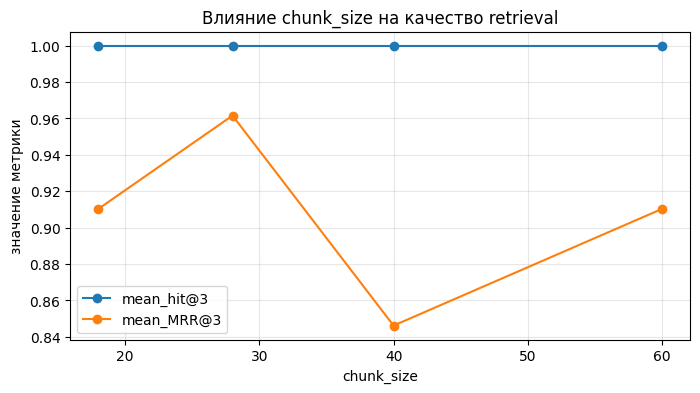

In [87]:
# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Обновляем базу знаний

In [88]:
documents = documents + new_documents

display(pd.DataFrame(new_documents)[["doc_id", "title"]])

new_queries = [
    "Как определить модель ответа и тип возвращаемых данных?",
    "Как реализовать простую аутентификацию OAuth2 с паролем и Bearer?",
    "Как использовать суб-зависимости?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

,doc_id,title
0,doc_15,Модель ответа — Возвращаемый тип
1,doc_16,Простая авторизация OAuth2 с паролем и «Bearer»
2,doc_17,Подзависимости


### Как baseline-база отвечает на новые запросы

**Запрос:** Как определить модель ответа и тип возвращаемых данных?

,rank,score,doc_id,title,chunk_text
0,1,0.553433,doc_07,Дополнительные модели,"в другом), и т.д. А все описанные выше модели ..."
1,2,0.515145,doc_12,Path-параметры,в общем случае `your_enum_member.value`: {* .....
2,3,0.501540,doc_03,Тело запроса,"данных. * Если данные некорректны, вернёт поня..."


**Запрос:** Как реализовать простую аутентификацию OAuth2 с паролем и Bearer?

,rank,score,doc_id,title,chunk_text
0,1,0.544202,doc_07,Дополнительные модели,содержать пароль. * **Модель для базы данных**...
1,2,0.457709,doc_07,Дополнительные модели,``` будет эквивалентно: ```Python UserInDB( us...
2,3,0.428175,doc_07,Дополнительные модели,из Pydantic { #pydantics-model-dump } `user_in...


**Запрос:** Как использовать суб-зависимости?

,rank,score,doc_id,title,chunk_text
0,1,0.475931,doc_06,Зависимости,и мощно { #simple-and-powerful } Хотя иерархич...
1,2,0.462791,doc_06,Зависимости,что должно быть выполнено перед вашей *функцие...
2,3,0.452366,doc_06,Зависимости,инъекция зависимостей («Dependency Injection»)...


## Переиндексация и сравнение до/после обновления

In [89]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    documents,
    chunk_size=50,
    overlap=6,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
qa_benchmark = qa_benchmark + [
    {
        "query_id": "q14",
        "query": "Как определить модель ответа и тип возвращаемых данных?",
        "relevant_doc_ids": ["doc_15"],
        "expected_keywords": ["ответ", "модель", "тип"],
    },
    {
        "query_id": "q15",
        "query": "Как реализовать простую аутентификацию OAuth2 с паролем и Bearer?",
        "relevant_doc_ids": ["doc_16"],
        "expected_keywords": ["OAuth2", "пароль", "токен"],
    },
    {
        "query_id": "q16",
        "query": "Как использовать суб-зависимости?",
        "relevant_doc_ids": ["doc_17"],
        "expected_keywords": ["суб-зависимость", "Depends"],
    },
]

before_update_eval = evaluate_benchmark(qa_benchmark, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(qa_benchmark, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

artifacts = updated_artifacts

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12602.16it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Как определить тело запроса с Pydantic?,doc_03,"doc_03, doc_07, doc_01",1,1.0,1.000000,1.0,"doc_15, doc_03, doc_07",1,1.0,0.500000,2
1,q02,Как работать с вложенными моделями?,doc_02,"doc_07, doc_02",1,1.0,0.500000,2.0,"doc_07, doc_02",1,1.0,0.500000,2
2,q03,Как использовать cookie-параметры?,doc_04,doc_04,1,1.0,1.000000,1.0,doc_04,1,1.0,1.000000,1
3,q04,Как создавать зависимости с yield?,doc_05,doc_05,1,1.0,1.000000,1.0,doc_05,1,1.0,1.000000,1
4,q05,Как объявлять обычные зависимости?,doc_06,doc_06,1,1.0,1.000000,1.0,"doc_17, doc_06",1,1.0,0.500000,2
5,q06,Как добавить дополнительные модели для докумен...,doc_07,"doc_07, doc_12",1,1.0,1.000000,1.0,"doc_07, doc_12",1,1.0,1.000000,1
6,q07,Как сделать первые шаги с FastAPI?,doc_08,"doc_08, doc_05",1,1.0,1.000000,1.0,"doc_08, doc_05",1,1.0,1.000000,1
7,q08,Как обрабатывать ошибки в приложении?,doc_09,"doc_12, doc_05, doc_09",1,1.0,0.333333,3.0,"doc_12, doc_05, doc_09",1,1.0,0.333333,3
8,q09,Как работать с header-параметрами?,doc_10,"doc_10, doc_11, doc_03",1,1.0,1.000000,1.0,"doc_10, doc_11, doc_03",1,1.0,1.000000,1
9,q10,Как настраивать конфигурацию операций маршрута?,doc_11,"doc_11, doc_12",1,1.0,1.000000,1.0,"doc_11, doc_12",1,1.0,1.000000,1


,metric,before_update,after_update,delta
0,mean_hit@3,0.812500,1.000000,0.1875
1,mean_recall@3,0.812500,1.000000,0.1875
2,mean_MRR@3,0.739583,0.864583,0.1250


### Как updated-база отвечает на новые запросы

**Запрос:** Как определить модель ответа и тип возвращаемых данных?

,rank,score,doc_id,title,chunk_text
0,1,0.680242,doc_15,Модель ответа — Возвращаемый тип,"важно для **безопасности**, ниже мы рассмотрим..."
1,2,0.653194,doc_15,Модель ответа — Возвращаемый тип,"возвращает больше данных, в ответ будут включе..."
2,3,0.650165,doc_15,Модель ответа — Возвращаемый тип,"от объявленного (например, Pydantic-модель). В..."


**Запрос:** Как реализовать простую аутентификацию OAuth2 с паролем и Bearer?

,rank,score,doc_id,title,chunk_text
0,1,0.799557,doc_16,Простая авторизация OAuth2 с паролем и «Bearer»,# Простая авторизация OAuth2 с паролем и «Bear...
1,2,0.581253,doc_16,Простая авторизация OAuth2 с паролем и «Bearer»,от реализации. Для OAuth2 это просто строки. /...
2,3,0.559706,doc_15,Модель ответа — Возвращаемый тип,Вместо этого мы можем создать входную модель с...


**Запрос:** Как использовать суб-зависимости?

,rank,score,doc_id,title,chunk_text
0,1,0.582305,doc_17,Подзависимости,# Подзависимости { #sub-dependencies } Вы може...
1,2,0.565128,doc_17,Подзависимости,"`q` как строку, а затем возвращает его. Это до..."
2,3,0.475931,doc_06,Зависимости,и мощно { #simple-and-powerful } Хотя иерархич...


In [90]:
# сохраним результат
df = comparison_df.copy()
df["changed"] = df["predicted_doc_ids_before"] != df["predicted_doc_ids_after"]
result = df[[
    "query",
    "predicted_doc_ids_before",
    "predicted_doc_ids_after",
    "changed"
]].rename(columns={
    "predicted_doc_ids_before": "before_retrieved_sources",
    "predicted_doc_ids_after": "after_retrieved_sources"
})
display(result)
result.to_csv("artifacts/retrieval_before_after_update.csv", index=False)

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Как определить тело запроса с Pydantic?,"doc_03, doc_07, doc_01","doc_15, doc_03, doc_07",True
1,Как работать с вложенными моделями?,"doc_07, doc_02","doc_07, doc_02",False
2,Как использовать cookie-параметры?,doc_04,doc_04,False
3,Как создавать зависимости с yield?,doc_05,doc_05,False
4,Как объявлять обычные зависимости?,doc_06,"doc_17, doc_06",True
5,Как добавить дополнительные модели для докумен...,"doc_07, doc_12","doc_07, doc_12",False
6,Как сделать первые шаги с FastAPI?,"doc_08, doc_05","doc_08, doc_05",False
7,Как обрабатывать ошибки в приложении?,"doc_12, doc_05, doc_09","doc_12, doc_05, doc_09",False
8,Как работать с header-параметрами?,"doc_10, doc_11, doc_03","doc_10, doc_11, doc_03",False
9,Как настраивать конфигурацию операций маршрута?,"doc_11, doc_12","doc_11, doc_12",False


## Baseline без retrieval

In [91]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]


def pick_best_sentences(query: str, text: str, top_n: int = 2) -> List[str]:
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentences).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    best_idx = np.argsort(-scores)[:top_n]
    return [sentences[i] for i in best_idx if scores[i] > 0]


def answer_without_retrieval(query: str, documents: List[Dict[str, str]]) -> Dict[str, object]:
    doc_texts = [doc["title"] + ". " + doc["text"] for doc in documents]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform(doc_texts + [query]).toarray().astype(np.float32)

    doc_vecs = matrix[:-1]
    query_vec = matrix[-1]

    doc_norms = np.linalg.norm(doc_vecs, axis=1) + 1e-12
    query_norm = np.linalg.norm(query_vec) + 1e-12
    scores = (doc_vecs @ query_vec) / (doc_norms * query_norm)

    best_idx = int(np.argmax(scores))
    best_doc = documents[best_idx]
    best_sentences = pick_best_sentences(query, best_doc["text"], top_n=2)

    if best_sentences:
        answer = " ".join(best_sentences)
    else:
        answer = (
            "Не удалось уверенно извлечь ответ без retrieval по чанкам. "
            "Система выбрала наиболее похожий документ целиком."
        )

    return {
        "answer": answer,
        "selected_doc_id": best_doc["doc_id"],
        "selected_title": best_doc["title"],
        "score": float(scores[best_idx]),
    }

In [92]:
baseline_example = answer_without_retrieval(
    "Как передавать заголовки в запросах?",
    documents,
)

display(pd.DataFrame([baseline_example]))

,answer,selected_doc_id,selected_title,score
0,///\n\n/// info | Информация\n\nЧтобы объявить...,doc_10,Header-параметры,0.049712


## Формируем контекст для mini-RAG

In [93]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | {row['title']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [94]:
query = "Что такое \"Схема\" данных?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Что такое "Схема" данных?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.570189,doc_08,Первые шаги,doc_08_chunk_09,"это спецификация, которая определяет, как опис..."
1,2,0.513978,doc_15,Модель ответа — Возвращаемый тип,doc_15_chunk_27,"итоге вернуть намного больше данных, чем ожида..."
2,3,0.496102,doc_07,Дополнительные модели,doc_07_chunk_12,"в другом), и т.д. А все описанные выше модели ..."


[Источник: doc_08 | Первые шаги | score=0.5702]
это спецификация, которая определяет, как описывать схему вашего API. Это определение схемы включает пути вашего API, возможные параметры, которые они принимают, и т.п. #### «Схема» данных { #data-schema } Термин «схема» также может относиться к форме некоторых данных, например, к содержимому JSON. В таком случае это будут атрибуты JSON, их

[Источник: doc_15 | Модель ответа — Возвращаемый тип | score=0.5140]
итоге вернуть намного больше данных, чем ожидали. Таким образом вы получаете лучшее из обоих миров: аннотации типов с **поддержкой инструментов** и **фильтрацию данных**. ## Посмотреть в документации { #see-it-in-the-docs } В автоматической документации вы увидите, что у входной и выходной моделей есть свои JSON Schema: <img src="/img/tutorial/response-model/image01.png"> И обе модели

[Источник: doc_07 | Дополнительные модели | score=0.4961]
в другом), и т.д. А все описанные выше модели используют много общих данных и дублируют назв

## Генератор ответа по найденному контексту

In [95]:
def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [96]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

#### «Схема» данных { #data-schema } Термин «схема» также может относиться к форме некоторых данных, например, к содержимому JSON. итоге вернуть намного больше данных, чем ожидали.


## Полный mini-RAG-пайплайн

In [97]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [98]:
rag_result = mini_rag_answer(
    "Что сделать, чтобы объявить тело запроса?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Что сделать, чтобы объявить тело запроса?

**Ответ:** Чтобы объявить тело **запроса**, используйте модели [Pydantic](https://docs.pydantic.dev/), со всей их мощью и преимуществами. ## Тело запроса + параметры пути + параметры запроса { #request-body-path-query-parameters } Вы также можете одновременно объявить параметры **тела**, **пути** и **запроса**.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.640200,doc_03,Тело запроса,doc_03_chunk_02,Ваш API почти всегда должен отправлять тело **...
1,2,0.613175,doc_03,Тело запроса,doc_03_chunk_01,# Тело запроса { #request-body } Когда вам нео...
2,3,0.528056,doc_03,Тело запроса,doc_03_chunk_17,## Тело запроса + параметры пути + параметры з...


## Сравнение: без retrieval vs с retrieval

In [99]:
comparison_queries = [
    "Как определить тело запроса с Pydantic?",
    "Как использовать path и query параметры?",
    "Как открыть интерактивную документацию API?",
    "Что происходит при ошибке валидации?",
    "Как работают зависимости в FastAPI?",
]

comparison_rows = []

for query in comparison_queries:
    baseline = answer_without_retrieval(query, documents)
    rag = mini_rag_answer(query, artifacts=artifacts, top_k=3)

    comparison_rows.append(
        {
            "query": query,
            "baseline_doc_id": baseline["selected_doc_id"],
            "baseline_score": baseline["score"],
            "baseline_answer": baseline["answer"],
            "rag_answer": rag["answer"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,query,baseline_doc_id,baseline_score,baseline_answer,rag_answer
0,Как определить тело запроса с Pydantic?,doc_03,0.177816,* Если параметр объявлен как тип **модели Pyda...,{* ../../docs_src/body/tutorial003_py310.py hl...
1,Как использовать path и query параметры?,doc_14,0.156212,# Query-параметры { #query-parameters }\n\nКог...,## Тело запроса + параметры пути + параметры з...
2,Как открыть интерактивную документацию API?,doc_12,0.044080,///\n\n## Документация { #documentation }\n\nИ...,/// ## Документация { #documentation } И тепер...
3,Что происходит при ошибке валидации?,doc_13,0.021829,"И ни редактор, ни Python не будут ругаться при...",Это очень полезно при разработке и отладке код...
4,Как работают зависимости в FastAPI?,doc_06,0.099113,На самом деле все (или большинство) веб-фреймв...,Другие распространённые термины для описания т...


In [100]:
for _, row in comparison_df.iterrows():
    display(Markdown(f"## Вопрос: {row['query']}"))
    display(Markdown(f"**Baseline без retrieval:** {row['baseline_answer']}"))
    display(Markdown(f"**Mini-RAG:** {row['rag_answer']}"))

## Вопрос: Как определить тело запроса с Pydantic?

**Baseline без retrieval:** * Если параметр объявлен как тип **модели Pydantic**, он будет интерпретирован как **тело** запроса. # Тело запроса { #request-body }

Когда вам необходимо отправить данные из клиента (например, браузера) в ваш API, вы отправляете их как **тело запроса**.

**Mini-RAG:** {* ../../docs_src/body/tutorial003_py310.py hl[15:16] *} ## Тело запроса + параметры пути параметры пути { #request-body-path-parameters } Вы можете одновременно объявить параметры пути и тело запроса.

## Вопрос: Как использовать path и query параметры?

**Baseline без retrieval:** # Query-параметры { #query-parameters }

Когда вы объявляете параметры функции, которые не являются параметрами пути, они автоматически интерпретируются как "query"-параметры. /// tip | Подсказка

Вы можете использовать класс `Enum` также, как ранее применяли его с [Path-параметрами](path-params.md#predefined-values).

...

**Baseline без retrieval:** И ни редактор, ни Python не будут ругаться при самом вызове функции — ошибка проявится лишь при операциях внутри. В таких случаях можно использовать **кастомную функцию-валидатор**, которая применяется после обычной валидации (например, после проверки, что значение — это `str`).

**Mini-RAG:** Это очень полезно при разработке и отладке кода, случаях можно использовать **кастомную функцию-валидатор**, которая применяется после обычной валидации (например, после проверки, что значение — это `str`).

## Вопрос: Как работают зависимости в FastAPI?

**Baseline без retrieval:** На самом деле все (или большинство) веб-фреймворков работают таким же образом. # Зависимости { #dependencies }

**FastAPI** имеет очень мощную, но интуитивную систему **<dfn title="также известно как: компоненты, ресурсы, провайдеры, сервисы, внедряемые зависимости">Инъекция зависимостей</dfn>**.

**Mini-RAG:** Другие распространённые термины для описания той же идеи «dependency injection»: * ресурсы * провайдеры * сервисы * внедряемые зависимости * компоненты ## Плагины **FastAPI** { #fastapi-plug-ins } Интеграции и «плагины» могут быть передать путь к файлу в команду `fastapi dev`, и она попытается определить объект приложения FastAPI для использования: ```console $ fastapi dev main.py ``` Но в этом случае вам придётся каждый раз помнить о передаче корректного пути при вызове команды `fastapi`.

## Возвращаем ответ вместе с источниками

In [101]:
query = "Как возвращать модель ответа и типы данных?"
rag_result = mini_rag_answer(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Вопрос: {query}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(rag_result["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Вопрос: Как возвращать модель ответа и типы данных?

**Ответ:** Например, вы можете хотеть **возвращать словарь** или объект из базы данных, но **объявить его как Pydantic-модель**. возвращает больше данных, в ответ будут включены только поля, объявленные в модели ответа.

,rank,score,doc_id,title,chunk_text
0,1,0.718384,doc_15,Модель ответа — Возвращаемый тип,"возвращает больше данных, в ответ будут включе..."
1,2,0.712823,doc_15,Модель ответа — Возвращаемый тип,"важно для **безопасности**, ниже мы рассмотрим..."
2,3,0.697347,doc_15,Модель ответа — Возвращаемый тип,"у *декоратора операции пути*, чтобы задавать м..."


## Мини-оценка качества на контрольных вопросах

In [102]:
def keyword_recall(answer: str, expected_keywords: List[str]) -> float:
    answer_lower = answer.lower()
    hits = sum(1 for kw in expected_keywords if kw.lower() in answer_lower)
    return hits / len(expected_keywords) if expected_keywords else np.nan


def evaluate_mini_rag(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []

    for item in benchmark_rows:
        query = item["query"]
        relevant_doc_ids = item["relevant_doc_ids"]
        expected_keywords = item["expected_keywords"]

        retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
        predicted_doc_ids = retrieved["doc_id"].tolist()
        retrieval_hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))

        baseline = answer_without_retrieval(query, documents)
        rag = mini_rag_answer(query, artifacts=artifacts, top_k=top_k)

        rows.append(
            {
                "query_id": item["query_id"],
                "query": query,
                "relevant_doc_ids": ", ".join(relevant_doc_ids),
                "predicted_doc_ids": ", ".join(predicted_doc_ids),
                f"retrieval_hit@{top_k}": retrieval_hit,
                "baseline_keyword_recall": keyword_recall(baseline["answer"], expected_keywords),
                "rag_keyword_recall": keyword_recall(rag["answer"], expected_keywords),
                "baseline_answer": baseline["answer"],
                "rag_answer": rag["answer"],
            }
        )

    return pd.DataFrame(rows)

In [103]:
evaluation_df = evaluate_mini_rag(qa_benchmark, artifacts=artifacts, top_k=3)
display(evaluation_df)

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Как определить тело запроса с Pydantic?,doc_03,"doc_15, doc_03, doc_07",1,0.666667,0.666667,* Если параметр объявлен как тип **модели Pyda...,{* ../../docs_src/body/tutorial003_py310.py hl...
1,q02,Как работать с вложенными моделями?,doc_02,"doc_07, doc_02, doc_02",1,0.000000,0.666667,"Без необходимости знать заранее, какие значени...",## Поля-списки { #list-fields } Вы можете опре...
2,q03,Как использовать cookie-параметры?,doc_04,"doc_04, doc_04, doc_04",1,1.000000,1.000000,///\n\n/// info | Дополнительная информация\n\...,# Параметры Cookie { #cookie-parameters } Вы м...
3,q04,Как создавать зависимости с yield?,doc_05,"doc_05, doc_05, doc_05",1,1.000000,0.500000,///\n\n## Зависимости с `yield` и `HTTPExcepti...,"**FastAPI** проследит за тем, чтобы «код выход..."
4,q05,Как объявлять обычные зависимости?,doc_06,"doc_17, doc_06, doc_17",1,0.000000,0.000000,И вы можете объявлять зависимости с `async def...,"`q` как строку, а затем возвращает его. # Подз..."
5,q06,Как добавить дополнительные модели для докумен...,doc_07,"doc_07, doc_07, doc_12",1,0.333333,0.666667,# Дополнительные модели { #extra-models }\n\nВ...,# Дополнительные модели { #extra-models } В пр...
6,q07,Как сделать первые шаги с FastAPI?,doc_08,"doc_08, doc_05, doc_08",1,0.666667,0.333333,## Первые шаги { #first-steps }\n\nДавайте рас...,# Первые шаги { #first-steps } Самый простой ф...
7,q08,Как обрабатывать ошибки в приложении?,doc_09,"doc_12, doc_05, doc_09",1,0.333333,0.000000,Но добавление аннотаций типов позволит вашему ...,"Обратите внимание, что в тексте ошибки явно ук..."
8,q09,Как работать с header-параметрами?,doc_10,"doc_10, doc_11, doc_03",1,1.000000,1.000000,## Импорт `Header` { #import-header }\n\nСперв...,## Импорт `Header` { #import-header } Сперва и...
9,q10,Как настраивать конфигурацию операций маршрута?,doc_11,"doc_11, doc_12, doc_12",1,0.333333,0.666667,"///\n\n<img src=""/img/tutorial/path-operation-...",# Конфигурация операций пути { #path-operation...


In [104]:
# сохраним результат
rag_examples = evaluation_df[[
    "query",
    "rag_answer",
    "predicted_doc_ids"
]].rename(columns={
    "query": "question",
    "rag_answer": "answer",
    "predicted_doc_ids": "retrieved_sources"
})
display(rag_examples)
rag_examples.to_csv("artifacts/rag_examples.csv", index=False)

,question,answer,retrieved_sources
0,Как определить тело запроса с Pydantic?,{* ../../docs_src/body/tutorial003_py310.py hl...,"doc_15, doc_03, doc_07"
1,Как работать с вложенными моделями?,## Поля-списки { #list-fields } Вы можете опре...,"doc_07, doc_02, doc_02"
2,Как использовать cookie-параметры?,# Параметры Cookie { #cookie-parameters } Вы м...,"doc_04, doc_04, doc_04"
3,Как создавать зависимости с yield?,"**FastAPI** проследит за тем, чтобы «код выход...","doc_05, doc_05, doc_05"
4,Как объявлять обычные зависимости?,"`q` как строку, а затем возвращает его. # Подз...","doc_17, doc_06, doc_17"
5,Как добавить дополнительные модели для докумен...,# Дополнительные модели { #extra-models } В пр...,"doc_07, doc_07, doc_12"
6,Как сделать первые шаги с FastAPI?,# Первые шаги { #first-steps } Самый простой ф...,"doc_08, doc_05, doc_08"
7,Как обрабатывать ошибки в приложении?,"Обратите внимание, что в тексте ошибки явно ук...","doc_12, doc_05, doc_09"
8,Как работать с header-параметрами?,## Импорт `Header` { #import-header } Сперва и...,"doc_10, doc_11, doc_03"
9,Как настраивать конфигурацию операций маршрута?,# Конфигурация операций пути { #path-operation...,"doc_11, doc_12, doc_12"


In [105]:
summary_df = pd.DataFrame(
    {
        "metric": ["mean_retrieval_hit@3", "mean_baseline_keyword_recall", "mean_rag_keyword_recall"],
        "value": [
            evaluation_df["retrieval_hit@3"].mean(),
            evaluation_df["baseline_keyword_recall"].mean(),
            evaluation_df["rag_keyword_recall"].mean(),
        ],
    }
)
display(summary_df)

,metric,value
0,mean_retrieval_hit@3,1.000000
1,mean_baseline_keyword_recall,0.562500
2,mean_rag_keyword_recall,0.552083


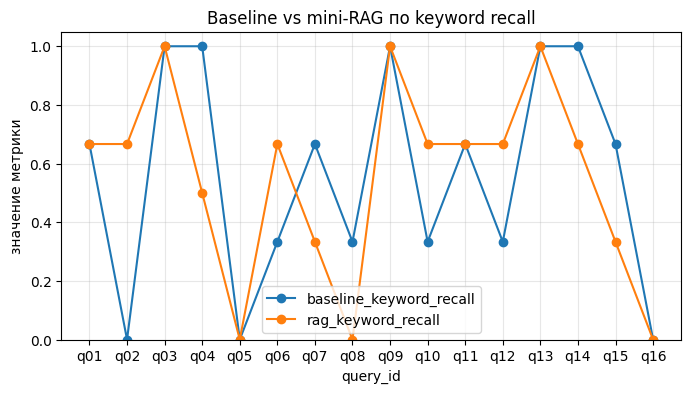

In [106]:
plt.figure(figsize=(8, 4))
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["baseline_keyword_recall"],
    marker="o",
    label="baseline_keyword_recall",
)
plt.plot(
    evaluation_df["query_id"],
    evaluation_df["rag_keyword_recall"],
    marker="o",
    label="rag_keyword_recall",
)
plt.ylim(0, 1.05)
plt.xlabel("query_id")
plt.ylabel("значение метрики")
plt.title("Baseline vs mini-RAG по keyword recall")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Разбор слабых мест и ошибок

In [107]:
weak_cases = evaluation_df[
    evaluation_df["rag_keyword_recall"] < evaluation_df["rag_keyword_recall"].max()
].reset_index(drop=True)

display(weak_cases if len(weak_cases) > 0 else evaluation_df.head(0))

if len(weak_cases) == 0:
    print("На этом маленьком benchmark все ответы mini-RAG достигли одинакового keyword recall.")
else:
    print("Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,retrieval_hit@3,baseline_keyword_recall,rag_keyword_recall,baseline_answer,rag_answer
0,q01,Как определить тело запроса с Pydantic?,doc_03,"doc_15, doc_03, doc_07",1,0.666667,0.666667,* Если параметр объявлен как тип **модели Pyda...,{* ../../docs_src/body/tutorial003_py310.py hl...
1,q02,Как работать с вложенными моделями?,doc_02,"doc_07, doc_02, doc_02",1,0.000000,0.666667,"Без необходимости знать заранее, какие значени...",## Поля-списки { #list-fields } Вы можете опре...
2,q04,Как создавать зависимости с yield?,doc_05,"doc_05, doc_05, doc_05",1,1.000000,0.500000,///\n\n## Зависимости с `yield` и `HTTPExcepti...,"**FastAPI** проследит за тем, чтобы «код выход..."
3,q05,Как объявлять обычные зависимости?,doc_06,"doc_17, doc_06, doc_17",1,0.000000,0.000000,И вы можете объявлять зависимости с `async def...,"`q` как строку, а затем возвращает его. # Подз..."
4,q06,Как добавить дополнительные модели для докумен...,doc_07,"doc_07, doc_07, doc_12",1,0.333333,0.666667,# Дополнительные модели { #extra-models }\n\nВ...,# Дополнительные модели { #extra-models } В пр...
5,q07,Как сделать первые шаги с FastAPI?,doc_08,"doc_08, doc_05, doc_08",1,0.666667,0.333333,## Первые шаги { #first-steps }\n\nДавайте рас...,# Первые шаги { #first-steps } Самый простой ф...
6,q08,Как обрабатывать ошибки в приложении?,doc_09,"doc_12, doc_05, doc_09",1,0.333333,0.000000,Но добавление аннотаций типов позволит вашему ...,"Обратите внимание, что в тексте ошибки явно ук..."
7,q10,Как настраивать конфигурацию операций маршрута?,doc_11,"doc_11, doc_12, doc_12",1,0.333333,0.666667,"///\n\n<img src=""/img/tutorial/path-operation-...",# Конфигурация операций пути { #path-operation...
8,q11,Как использовать path-параметры?,doc_12,"doc_12, doc_12, doc_14",1,0.666667,0.666667,# Параметры Cookie { #cookie-parameters }\n\nВ...,# Path-параметры { #path-parameters } Вы может...
9,q12,Как валидировать query-параметры и строки?,doc_13,"doc_13, doc_14, doc_14",1,0.333333,0.666667,# Query-параметры { #query-parameters }\n\nКог...,# Query-параметры и валидация строк { #query-p...


Эти вопросы стоит разобрать вручную: проблема может быть в retrieval, чанкинге или самом генераторе ответа.


In [108]:

for _, row in weak_cases.iterrows():
    display(Markdown(f"### Слабый кейс: {row['query']}"))
    rag = mini_rag_answer(row["query"], artifacts=artifacts, top_k=3)
    display(Markdown(f"**Ответ mini-RAG:** {rag['answer']}"))
    display(rag["sources"][["rank", "score", "doc_id", "title", "chunk_text"]])

### Слабый кейс: Как определить тело запроса с Pydantic?

**Ответ mini-RAG:** {* ../../docs_src/body/tutorial003_py310.py hl[15:16] *} ## Тело запроса + параметры пути параметры пути { #request-body-path-parameters } Вы можете одновременно объявить параметры пути и тело запроса.

,rank,score,doc_id,title,chunk_text
0,1,0.599045,doc_15,Модель ответа — Возвращаемый тип,"| Примечание Обратите внимание, что `response_..."
1,2,0.590848,doc_03,Тело запроса,параметры пути { #request-body-path-parameters...
2,3,0.578704,doc_07,Дополнительные модели,из Pydantic { #pydantics-model-dump } `user_in...


### Слабый кейс: Как работать с вложенными моделями?

**Ответ mini-RAG:** ## Поля-списки { #list-fields } Вы можете определить атрибут как подтип. определить модель `Image`: {* ../../docs_src/body_nested_models/tutorial004_py310.py hl[7:9] *} ### Использование подмодели как типа { #use-the-submodel-as-a-type } Также мы можем использовать эту модель как тип атрибута: {* ../../docs_src/body_nested_models/tutorial004_py310.py hl[18] *} Это означает, что **FastAPI** будет ожидать тело запроса, аналогичное этому: ```JSON { "name": "Foo", "description": "The pretender", "price": 42.0, "tax": 3.2, "tags":

...

**Ответ mini-RAG:** # Простая авторизация OAuth2 с паролем и «Bearer» { #simple-oauth2-with-password-and-bearer } Теперь, отталкиваясь от предыдущей главы, добавим недостающие части, чтобы получить полный поток безопасности. Для OAuth2 это просто строки.

,rank,score,doc_id,title,chunk_text
0,1,0.799557,doc_16,Простая авторизация OAuth2 с паролем и «Bearer»,# Простая авторизация OAuth2 с паролем и «Bear...
1,2,0.581253,doc_16,Простая авторизация OAuth2 с паролем и «Bearer»,от реализации. Для OAuth2 это просто строки. /...
2,3,0.559706,doc_15,Модель ответа — Возвращаемый тип,Вместо этого мы можем создать входную модель с...


### Слабый кейс: Как использовать суб-зависимости?

**Ответ mini-RAG:** Вы можете определять зависимости, которые, в свою очередь, могут иметь собственные зависимости. `q` как строку, а затем возвращает его.

,rank,score,doc_id,title,chunk_text
0,1,0.582305,doc_17,Подзависимости,# Подзависимости { #sub-dependencies } Вы може...
1,2,0.565128,doc_17,Подзависимости,"`q` как строку, а затем возвращает его. Это до..."
2,3,0.475931,doc_06,Зависимости,и мощно { #simple-and-powerful } Хотя иерархич...


## Анализ ошибок

Прокомментируем несколько слабых и пограничных кейсов:

1. Как определить тело запроса с Pydantic?

- Вернулись куски, где одновременно упоминяются параметры пути и тело запроса, вместо прямого объяснения модели тела запроса
- Причина скорее всего в формулировке вопроса

2. Как работать с вложенными моделями?

- Основной результат содержит примеры использования списков и подмоделей, но не дает простого прямого ответа
- Причина в составе контекста - он слишком фрагментарный, mini-rag захватывает несколько соседних чанков, что разбавляет фокус

3. Как создавать зависимости с yield?

- Mini-Rag вернул фрагменты с подробной механикой выполнения кода после yield, но без простого объяснения принципа
- Причина возможно в формулировке запроса

4. Как объявлять обычные зависимости?

- Основной ответ вернул информацию о подзависимостях, часть текста о Depends оказалась во 2/3 чанке
- Причина в неполноте базы данных/слабой сегментации текста

**Вывод** - проблемы часто бывают в :
- Фрагментарности контекста (чанки пересекаются или слишком малы)
- Общей формулировкой вопросов
- Частичной неполнотой базы знаний в некоторых местах